# KNN Classification Test

## Fetch Data

In [8]:
import pandas as pd

data = pd.read_csv('../processed_data/train_test.csv')
data

,Unnamed: 0,tourney_id,1_ht,1_age,2_ht,2_age,best_of,1_rank_points,2_rank_points,sets_played,...,2_right,pressure,court_speed,court_bounce,court_friction,asymmetry,age_diff,height_diff,rank_points_diff,winner_1
0,0,2023-M-ITF-CYP-05A-2023,185,27.6,180,25.9,3,4,32,3.0,...,True,1,2,2,2,False,1.700001,-5,28,0
1,1,2022-580,185,25.7,178,26.5,3,401,385,3.0,...,True,8,2,2,2,False,0.799999,7,16,1
2,2,2023-M-ITF-TUN-11A-2023,175,24.1,178,19.9,3,159,100,3.0,...,True,2,2,2,2,False,4.200001,3,-59,0
3,3,2023-560,185,33.2,183,21.7,3,254,442,2.0,...,False,8,2,2,2,False,11.500000,-2,188,0
4,4,2020-7077,185,26.9,188,24.1,3,269,296,2.0,...,True,3,1,3,3,False,-2.799999,-3,-27,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85808,85808,2022-M-ITF-DOM-08A-2022,183,18.7,193,29.2,3,31,46,2.0,...,True,1,2,2,2,False,10.500000,-10,-15,1
85809,85809,2023-M-ITF-TUR-02A-2023,180,28.2,185,23.9,3,64,106,2.0,...,True,1,1,3,3,True,4.300001,5,42,0
85810,85810,2024-560,183,28.2,185,32.4,3,459,273,3.0,...,True,8,2,2,2,False,-4.200001,2,-186,0
85811,85811,2023-M-ITF-GER-02A-2023,188,19.5,193,18.3,3,102,3,2.0,...,True,1,2,2,2,False,-1.200001,-5,99,1


In [24]:
data.columns

Index(['Unnamed: 0', 'tourney_id', '1_ht', '1_age', '2_ht', '2_age', 'best_of',
       '1_rank_points', '2_rank_points', 'sets_played', '1_ambidextrous',
       '1_left', '1_right', '2_ambidextrous', '2_left', '2_right', 'pressure',
       'court_speed', 'court_bounce', 'court_friction', 'asymmetry',
       'age_diff', 'height_diff', 'rank_points_diff', 'winner_1'],
      dtype='str')

## Pipeline Implementation

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier

In [3]:
# crossed, individual, mixed, and all feature models
# expected that individual feature models will require a lower k-value
crossed_feature_set = ['pressure', 'court_speed', 'court_bounce', 'court_friction', 'asymmetry', 'age_diff', 'height_diff', 'rank_points_diff']

individual_feature_set = ['1_ht', '1_age', '2_ht', '2_age', '1_rank_points', '2_rank_points', '1_ambidextrous', '1_left', '1_right', '2_ambidextrous', '2_left', '2_right', 'pressure', 'court_speed', 'court_bounce', 'court_friction']

mixed_feature_set = ['1_ht', '1_age', '2_ht', '2_age', '1_rank_points', '2_rank_points', 'pressure', 'court_speed', 'court_bounce', 'court_friction', 'asymmetry', 'age_diff', 'height_diff', 'rank_points_diff']

all_feature_set = ['1_ht', '1_age', '2_ht', '2_age', '1_rank_points', '2_rank_points', '1_ambidextrous', '1_left', '1_right', '2_ambidextrous', '2_left', '2_right', 'pressure', 'court_speed', 'court_bounce', 'court_friction', 'asymmetry', 'age_diff', 'height_diff', 'rank_points_diff']

one_hot_encoded_features = {'1_ambidextrous', '1_left', '1_right', '2_ambidextrous', '2_left', '2_right', 'asymmetry'}

feature_sets = {
    'crossed': crossed_feature_set,
    'individual': individual_feature_set,
    'mixed': mixed_feature_set,
    'all': all_feature_set
}

param_grid = {
    "knn__n_neighbors": [2, 4, 6, 8, 10, 15, 20, 30, 50],
    "knn__weights": ['uniform', 'distance'],
    "knn__p": [1, 2]
}

In [4]:
def pipe(feature_set_name):
    features = feature_sets[feature_set_name]
    
    # Scale only numeric features
    scaler = ColumnTransformer(
        transformers=[
            ('numeric', StandardScaler(), [feature for feature in features if feature not in one_hot_encoded_features]),
            ('one_hot', 'passthrough', [feature for feature in features if feature in one_hot_encoded_features])
        ]
    )
    
    # Pipeline
    pipeline = Pipeline([
        ('scaling', scaler),
        # ('nca', NeighborhoodComponentsAnalysis(random_state=42)),
        ('knn', KNeighborsClassifier())
    ])
    
    # Cross validation-based hyperparameter optimization
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='accuracy',
        cv=5,
        n_jobs=-1,
        verbose=3
    )
    
    grid.fit(data[features], data['winner_1'])
    
    # Results
    return {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    

In [28]:
from tqdm.auto import tqdm

results = {}

for feature_set_name in tqdm(feature_sets.keys()):
    results[feature_set_name] = pipe(feature_set_name)

results

  0%|          | 0/4 [00:00<?, ?it/s]

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits


{'crossed': {'best_score': np.float64(0.502651078161888),
  'best_params': {'knn__n_neighbors': 50,
   'knn__p': 2,
   'knn__weights': 'uniform'}},
 'individual': {'best_score': np.float64(0.5682006298078915),
  'best_params': {'knn__n_neighbors': 50,
   'knn__p': 1,
   'knn__weights': 'distance'}},
 'mixed': {'best_score': np.float64(0.9903511083562778),
  'best_params': {'knn__n_neighbors': 50,
   'knn__p': 2,
   'knn__weights': 'distance'}},
 'all': {'best_score': np.float64(0.9875892861974659),
  'best_params': {'knn__n_neighbors': 50,
   'knn__p': 2,
   'knn__weights': 'distance'}}}

In [30]:
best_score = 0

for feature_set_name, result in results.items():
    best_score = max(best_score, result['best_score'])
    
    print(f" ----- {feature_set_name} ----- ".upper())
    print(f"\t Best Score: {result['best_score']}")
    print(f"\t Best Params: {result['best_params']}")
    print()

 ----- CROSSED ----- 
	 Best Score: 0.502651078161888
	 Best Params: {'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'uniform'}

 ----- INDIVIDUAL ----- 
	 Best Score: 0.5682006298078915
	 Best Params: {'knn__n_neighbors': 50, 'knn__p': 1, 'knn__weights': 'distance'}

 ----- MIXED ----- 
	 Best Score: 0.9903511083562778
	 Best Params: {'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance'}

 ----- ALL ----- 
	 Best Score: 0.9875892861974659
	 Best Params: {'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance'}



## Model Evaluation and Refinement

In [49]:
import numpy as np

In [12]:
# Model setup
from sklearn.model_selection import train_test_split

X, y = data[feature_sets['mixed']], data['winner_1']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Remove knn__ prefix from best_params
best_params = { key.replace('knn__', '') : value for key, value in results['mixed']['best_params'].items() }
best_params['n_jobs'] = -1

knn = KNeighborsClassifier(**best_params)
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.9953388102313115

In [14]:
test = pd.concat([X_test, y_test], axis=1)

winner = test[test['winner_1'] == 1]
loser = test[test['winner_1'] == 0]

winner_X = winner.drop(columns=['winner_1'])
loser_X = loser.drop(columns=['winner_1'])

winner_y = winner['winner_1'] # a bunch of 1s
loser_y = loser['winner_1']   # a bunch of 0s

knn.score(winner_X, winner_y), knn.score(loser_X, loser_y) # expected to see equal accuracy between the two

(0.9950842696629213, 0.995591135862629)

### Feature Dependence

In [52]:
mixed_feature_set

['1_ht',
 '1_age',
 '2_ht',
 '2_age',
 '1_rank_points',
 '2_rank_points',
 'pressure',
 'court_speed',
 'court_bounce',
 'court_friction',
 'asymmetry',
 'age_diff',
 'height_diff',
 'rank_points_diff']

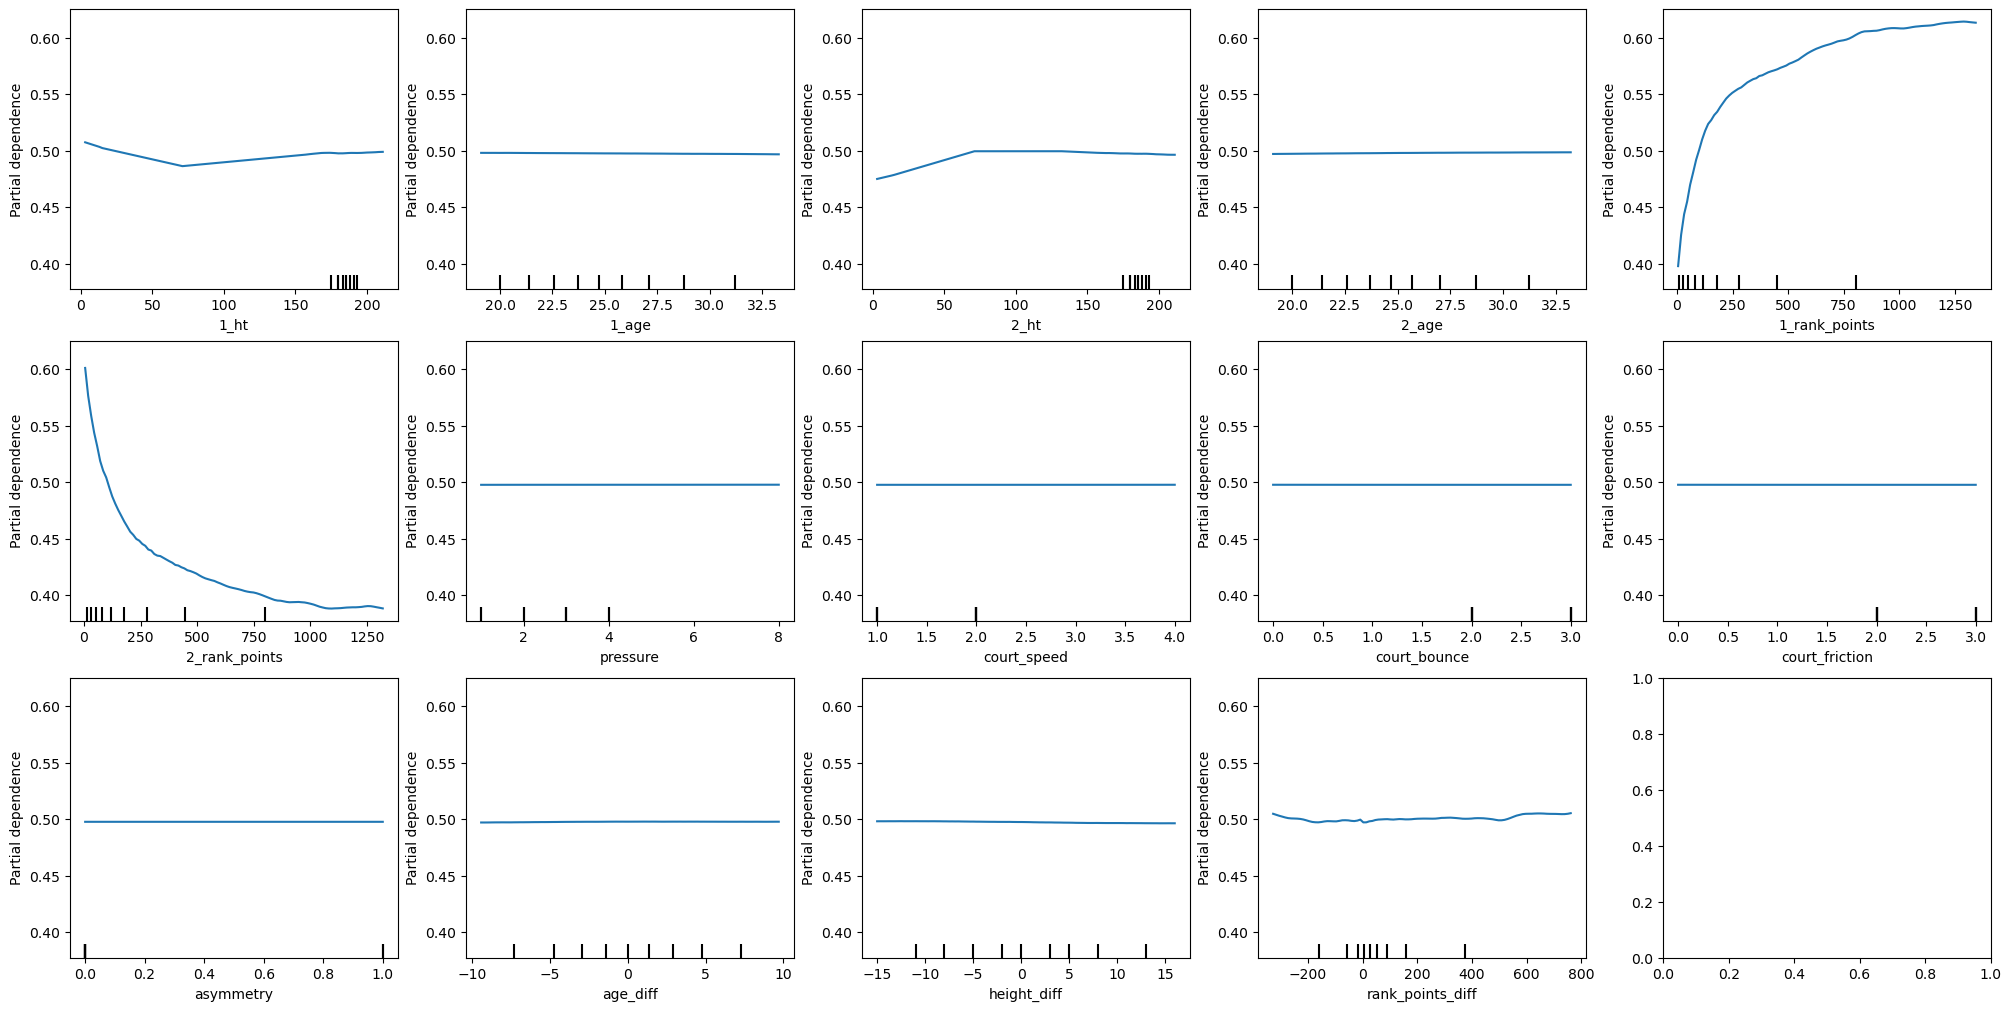

In [55]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Prevent error due to integer data type in PartialDependenceDisplay
X_testf = X_test.astype(np.float64)

# All features in one plot
fig, ax = plt.subplots(3, 5, figsize=(20, 10), constrained_layout=True)
ax_flat = ax.ravel() # 14 features, 15 subplots

PartialDependenceDisplay.from_estimator(
    knn,
    X_testf,
    features=mixed_feature_set,
    ax=ax_flat[:len(mixed_feature_set)]
)

In [58]:
# Hypothesis:
# Theoretically age, pressure, court_speed, bounce, friction, asymmetry, and height diff have negligible impact from PDPs
# Rank points diff has a minimal impact

new_feature_set = list(set(mixed_feature_set).difference({'1_age', '2_age', 'age_diff', 'pressure', 'court_speed', 'court_bounce', 'court_friction', 'asymmetry', 'height_diff'}))
new_feature_set_2 = list(set(new_feature_set).difference({'rank_points_diff'}))

X_train_new = X_train[new_feature_set]
X_test_new = X_test[new_feature_set]

X_train_new_2 = X_train[new_feature_set_2]
X_test_new_2 = X_test[new_feature_set_2]

knn_new = KNeighborsClassifier(**best_params)
knn_new_2 = KNeighborsClassifier(**best_params)

knn_new.fit(X_train_new, y_train)
knn_new_2.fit(X_train_new_2, y_train)

knn_new.score(X_test_new, y_test), knn_new_2.score(X_test_new_2, y_test)

(0.987589582240867, 0.6141700168968129)

In [65]:
new_feature_set, new_feature_set_2

(['2_rank_points', 'rank_points_diff', '1_rank_points', '2_ht', '1_ht'],
 ['1_rank_points', '2_ht', '2_rank_points', '1_ht'])

In [64]:
# Models became slightly less accurate but much more lightweight
# Rank points diff is very impactful, seems to provide extra weight to the points themselves with a new feature set

keys = list(results.keys())
for key in keys:
    if key != 'mixed':
        results.pop(key)

new_sets = {
    "set_1" : new_feature_set,
    "set_2" : new_feature_set_2
}
feature_sets.update(new_sets)

for set_name in tqdm(new_sets.keys()):
    results[set_name] = pipe(set_name)

best_score = 0

for feature_set_name, result in results.items():
    best_score = max(best_score, result['best_score'])
    
    print(f" ----- {feature_set_name} ----- ".upper())
    print(f"\t Best Score: {result['best_score']}")
    print(f"\t Best Params: {result['best_params']}")
    print()

  0%|          | 0/2 [00:00<?, ?it/s]

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
 ----- MIXED ----- 
	 Best Score: 0.9903511083562778
	 Best Params: {'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance'}

 ----- SET_1 ----- 
	 Best Score: 0.9508699544282603
	 Best Params: {'knn__n_neighbors': 2, 'knn__p': 2, 'knn__weights': 'distance'}

 ----- SET_2 ----- 
	 Best Score: 0.6161304665440979
	 Best Params: {'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'uniform'}



Heights, rank points, and rank point differences are the most important features.

Overall, mixed proved to be the best feature combination for accuracy, while set_1 is much more lightweight and retains an acceptable level of accuracy. Through the examination of set_2's performance, it becomes clear that rank_points_diff is a very important crossed feature to help the model. Moving forward with the assumption that compute is not a significant restriction and continuing with the mixed feature set.

For set 2 the n_neighbors is maxed out while the weights are uniform suggesting underfitting/over-generalizing behavior.

### Model Refinement

In [66]:
param_grid = {
    "knn__n_neighbors": [40, 45, 50, 55, 60, 70, 80, 90, 100],
    "knn__weights": ['uniform', 'distance'],
    "knn__p": [1, 2]
}

results['mixed'] = pipe('mixed')
print(" ----- MIXED ----- ")
print(f"\t Best Score: {results['mixed']['best_score']}")
print(f"\t Best Params: {results['mixed']['best_params']}")
print()

Fitting 5 folds for each of 36 candidates, totalling 180 fits
 ----- MIXED ----- 
	 Best Score: 0.9905142452451916
	 Best Params: {'knn__n_neighbors': 70, 'knn__p': 2, 'knn__weights': 'distance'}



In [67]:
param_grid = {
    "knn__n_neighbors": [65, 68, 70, 73, 75],
    "knn__weights": ['distance'],
    "knn__p": [2]
}

results['mixed'] = pipe('mixed')
print(" ----- MIXED ----- ")
print(f"\t Best Score: {results['mixed']['best_score']}")
print(f"\t Best Params: {results['mixed']['best_params']}")
print()

Fitting 5 folds for each of 5 candidates, totalling 25 fits
 ----- MIXED ----- 
	 Best Score: 0.9905142472821875
	 Best Params: {'knn__n_neighbors': 65, 'knn__p': 2, 'knn__weights': 'distance'}



In [9]:
param_grid = {
    "knn__n_neighbors": range(63, 68),
    "knn__weights": ['distance'],
    "knn__p": [2]
}

results['mixed'] = pipe('mixed')
print(" ----- MIXED ----- ")
print(f"\t Best Score: {results['mixed']['best_score']}")
print(f"\t Best Params: {results['mixed']['best_params']}")
print()

Fitting 5 folds for each of 5 candidates, totalling 25 fits
 ----- MIXED ----- 
	 Best Score: 0.9905142472821875
	 Best Params: {'knn__n_neighbors': 65, 'knn__p': 2, 'knn__weights': 'distance'}



In [10]:
best_params = { key.replace('knn__', '') : value for key, value in results['mixed']['best_params'].items() }
best_params['n_jobs'] = -1

Overall best parameters for KNN:
 - N-neighbors: 65
 - Euclidean Distance
 - Weighted by Distance

Results in an accuracy of over 99%

### Accuracy Distribution

In [11]:
mixed_feature_set

['1_ht',
 '1_age',
 '2_ht',
 '2_age',
 '1_rank_points',
 '2_rank_points',
 'pressure',
 'court_speed',
 'court_bounce',
 'court_friction',
 'asymmetry',
 'age_diff',
 'height_diff',
 'rank_points_diff']

In [ ]:
# Checking accuracy distribution over tournament level, rank points, heights, and ages
knn = KNeighborsClassifier(**best_params)
knn.fit(X_train, y_train)
test['accurate'] = test['winner_1'] == knn.predict(X_test)
test['accurate'].sum() / test['accurate'].count()

np.float64(0.9953388102313115)

In [ ]:
# pressure_mapping = {
#     'G': 8, # Grand Slam
#     'F': 7, # Finals
#     'D': 6, # Davis Cup
#     'M': 5, # Masters 1000
#     'A': 4, # ATP Tour
#     'C': 3, # Challenger
#     25: 2,  # ITF 25K
#     15: 1,  # ITF 15K
#     'S': 0, # Satellite (not in data)
# }

<Axes: xlabel='Tournament Level', ylabel='Accuracy'>

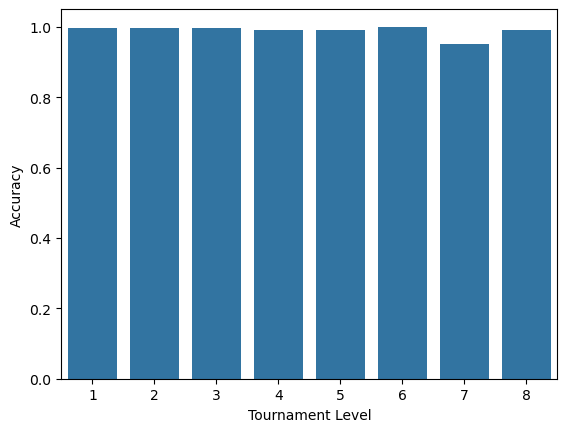

In [ ]:
import seaborn as sns

# tournament level
tournament_grouping = (
    test[['pressure', 'accurate']].groupby('pressure', as_index=False)
                                .agg(lambda s: s.sum() / s.count())
                                .rename(columns={
                                    'pressure' : 'Tournament Level',
                                    'accurate' : 'Accuracy'
                                    }
                                )
)

sns.barplot(data=tournament_grouping, x='Tournament Level', y='Accuracy')

In [21]:
test['rank_points_diff'].describe()

count    17163.000000
mean       135.550487
std        860.661893
min      -7862.000000
25%        -36.000000
50%         28.000000
75%        116.000000
max      10826.000000
Name: rank_points_diff, dtype: float64

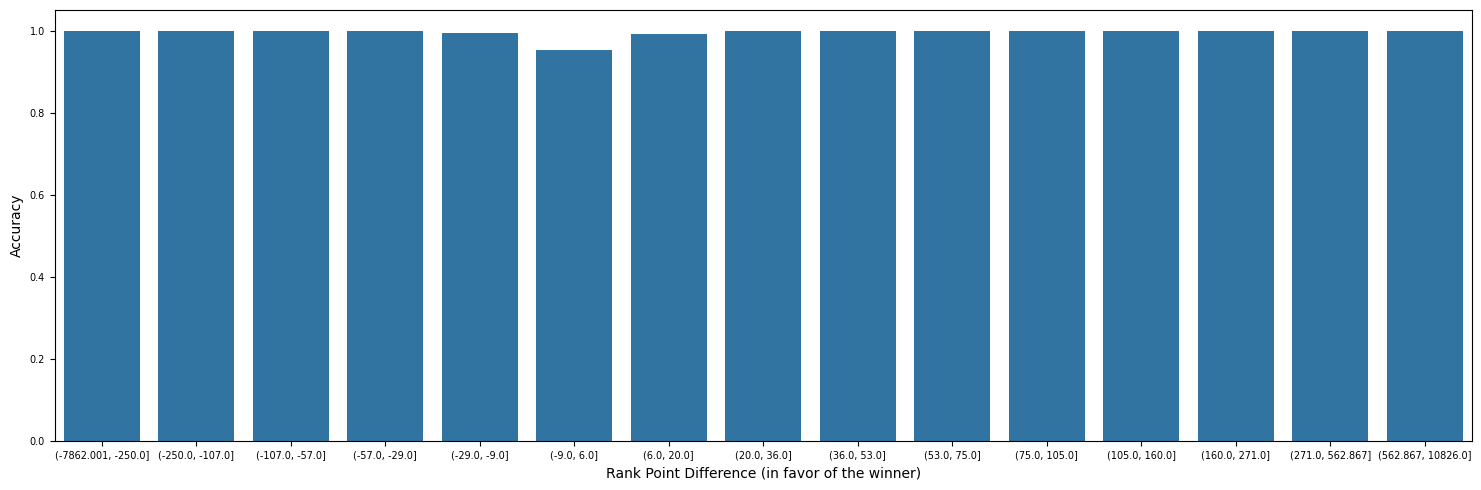

In [ ]:
# rank points
rank_diff = test[['accurate']].copy()
rank_diff['interval'] = pd.qcut(test['rank_points_diff'], 15)
rank_diff_grouping = (
    rank_diff.groupby('interval', as_index=False)
             .agg(lambda s: s.sum() / s.count())
             .rename(columns={
                 'interval' : 'Rank Point Difference (in favor of the winner)',
                 'accurate' : 'Accuracy'
                 }
             )
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.tick_params(axis="both", labelsize=7)
sns.barplot(
    data=rank_diff_grouping,
    x='Rank Point Difference (in favor of the winner)',
    y='Accuracy',
    ax=ax
)
plt.tight_layout()

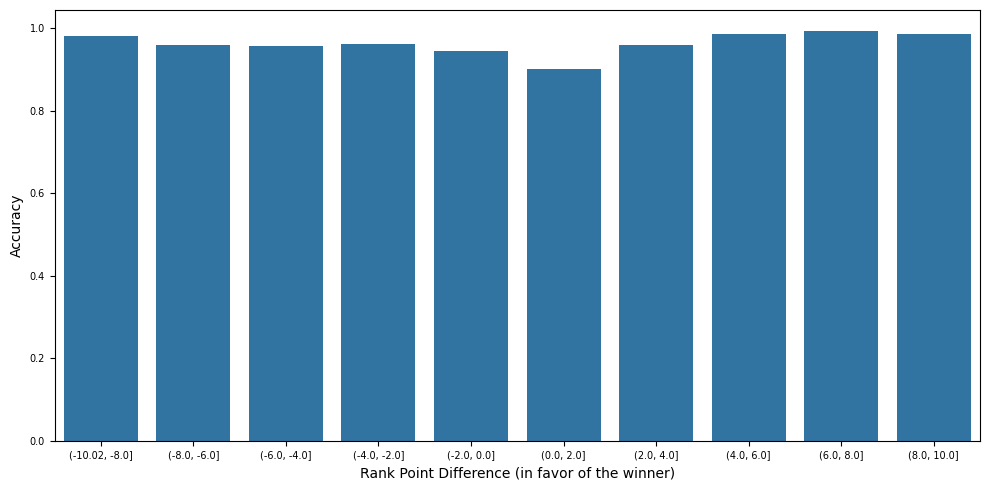

In [ ]:
# rank points
rank_diff = (test[['rank_points_diff', 'accurate']])[(test['rank_points_diff'] >= -10) & (test['rank_points_diff'] <= 10)]

rank_diff['interval'] = pd.cut(rank_diff['rank_points_diff'], 10)
rank_diff.drop('rank_points_diff', axis=1, inplace=True)

rank_diff_grouping = (
    rank_diff.groupby('interval', as_index=False)
             .agg(lambda s: s.sum() / s.count())
             .rename(columns={
                 'interval' : 'Rank Point Difference (in favor of the winner)',
                 'accurate' : 'Accuracy'
                 }
             )
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.tick_params(axis="both", labelsize=7)
sns.barplot(
    data=rank_diff_grouping,
    x='Rank Point Difference (in favor of the winner)',
    y='Accuracy',
    ax=ax
)
plt.tight_layout()

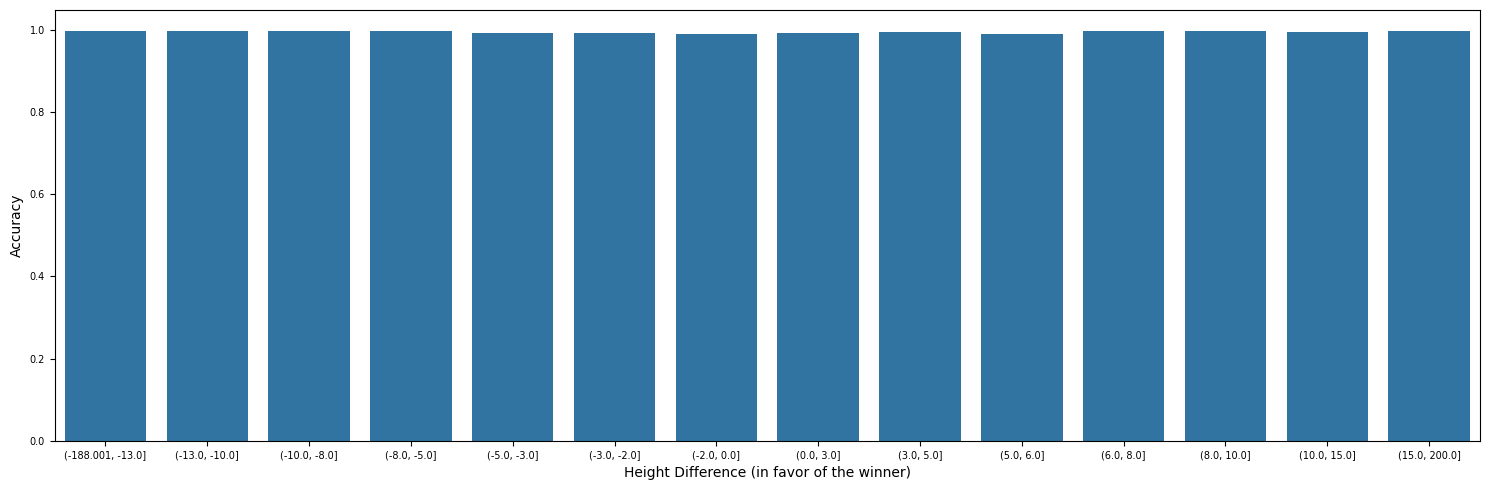

In [ ]:
# height
ht_diff = test[['accurate']].copy()
ht_diff['interval'] = pd.qcut(test['height_diff'], 15, duplicates='drop')
ht_diff_grouping = (
    ht_diff.groupby('interval', as_index=False)
           .agg(lambda s: s.sum() / s.count())
           .rename(columns={
               'interval' : 'Height Difference (in favor of the winner)',
               'accurate' : 'Accuracy'
               }
           )
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.tick_params(axis="both", labelsize=7)
sns.barplot(
    data=ht_diff_grouping,
    x='Height Difference (in favor of the winner)',
    y='Accuracy',
    ax=ax
)
plt.tight_layout()

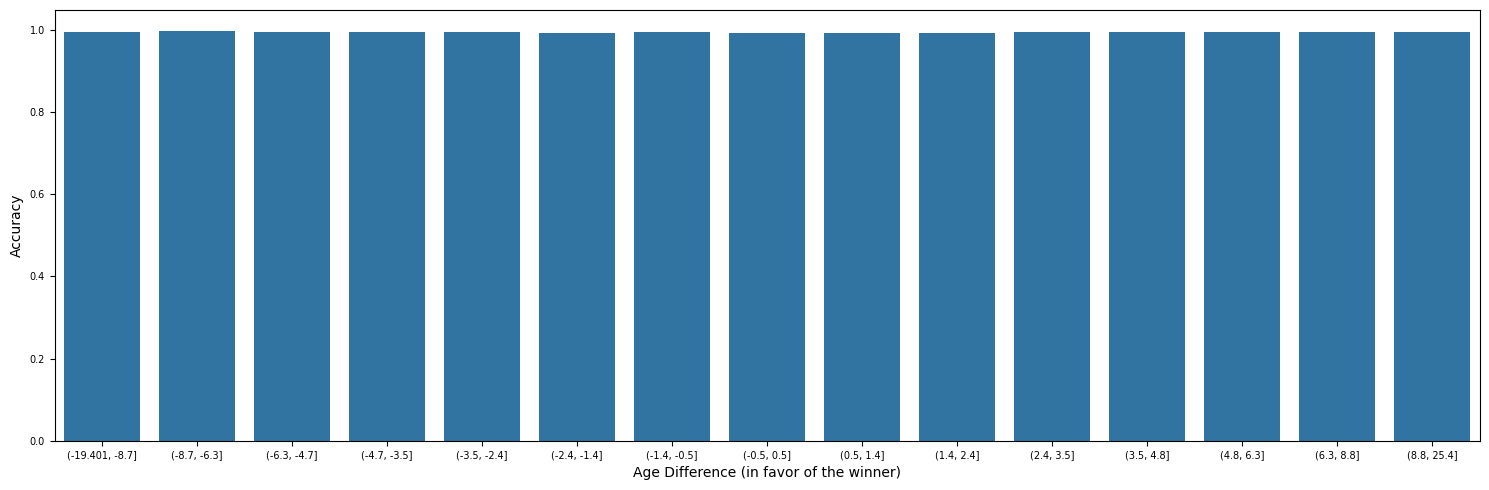

In [ ]:
# age
age_diff = test[['accurate']].copy()
age_diff['interval'] = pd.qcut(test['age_diff'], 15, duplicates='drop')
age_diff_grouping = (
    age_diff.groupby('interval', as_index=False)
            .agg(lambda s: s.sum() / s.count())
            .rename(columns={
                'interval' : 'Age Difference (in favor of the winner)',
                'accurate' : 'Accuracy'
                }
            )
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.tick_params(axis="both", labelsize=7)
sns.barplot(
    data=age_diff_grouping,
    x='Age Difference (in favor of the winner)',
    y='Accuracy',
    ax=ax
)
plt.tight_layout()

## Conclusion

In [52]:
# Export model
import joblib

final = KNeighborsClassifier(**best_params)
final.fit(X, y)

joblib.dump(final, "knn.pkl")

['knn.pkl']